<h1 style="width:50px;height:50px;">Setup</h1>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<h1 style="height:60px; color:red;">Task 2.1</h1>

<h1 style="width:100%;height:40px;">Top 10 Nations All time Goals</h1>

Text(0.5, 0, 'Teams')

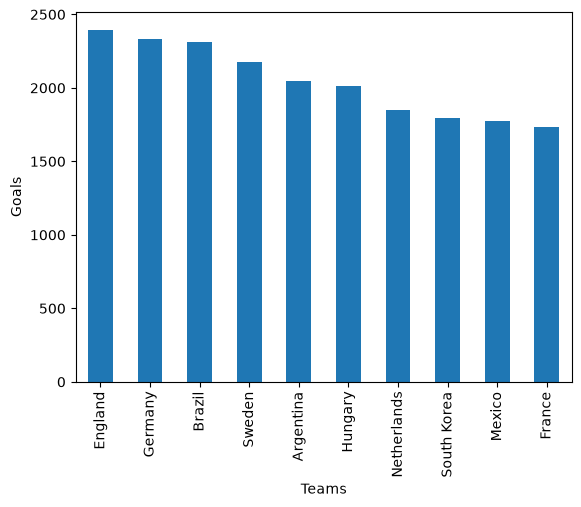

In [3]:
df=pd.read_csv("results.csv")
df=df.dropna()
teams=pd.concat([df["home_team"],df["away_team"]])
goals=pd.concat([df["home_score"],df["away_score"]])
team_goals=pd.DataFrame({"team":teams,"goals":goals})
top_10_nations=team_goals.groupby("team")["goals"].sum().sort_values(ascending=False).head(10)
top_10_nations.plot.bar()
plt.ylabel("Goals")
plt.xlabel("Teams")

<h1 style="width:100%;height:40px;">Top 10 Goalscorers of All time</h1>

Text(0, 0.5, 'Goals')

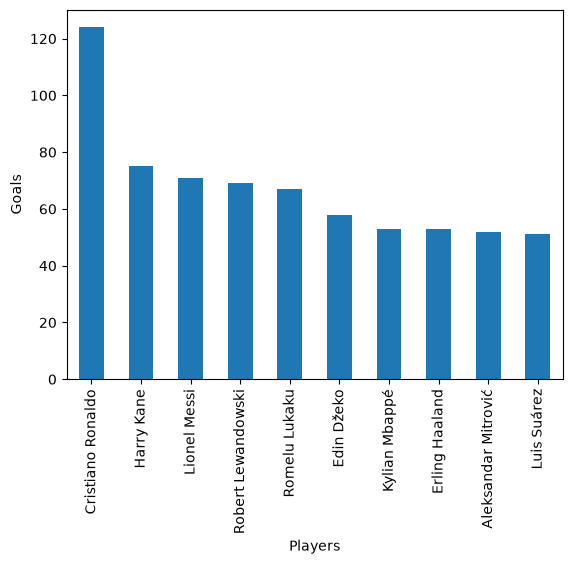

In [4]:
df=pd.read_csv("goalscorers.csv")
df=df.dropna()
scorers=df[df["own_goal"]==False]["scorer"].value_counts().sort_values(ascending=False).head(10)
scorers.plot.bar()
plt.xlabel("Players")
plt.ylabel("Goals")

<h1 style="width:100%;height:50px;">Top 10 Countries with highest average points</h1>

Text(0, 0.5, 'Average Points')

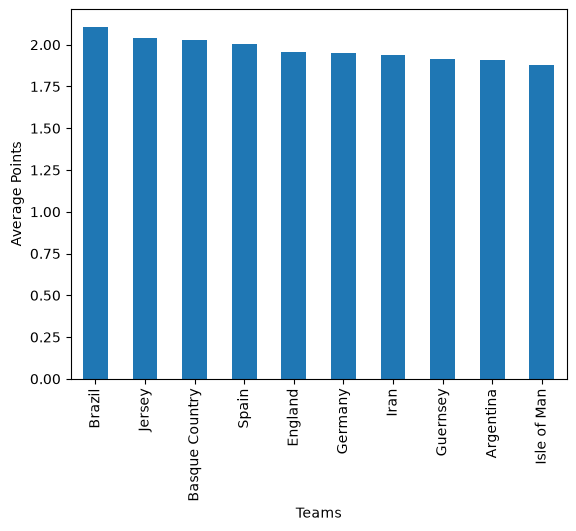

In [5]:
df=pd.read_csv("results.csv")
df=df.dropna()
df["home_points"]=(df["home_score"]>df["away_score"])*3 | (df["home_score"]==df["away_score"]) *1
df["away_points"]=(df["home_score"]<df["away_score"])*3 | (df["home_score"]==df["away_score"])*1
teams=pd.concat([df["home_team"],df["away_team"]])
points=pd.concat([df["home_points"],df["away_points"]]) 
goals=pd.concat([df["home_score"],df["away_score"]])
team_points=pd.DataFrame({"team":teams,"points":points,"goals":goals})
team_points=team_points[team_points["team"].map(team_points["team"].value_counts())>50] #Since value_counts() returns a series length that doesnt match the original one we cant do condition however it's keys and values are exactly what we want to map so we temporarily replace the teams values with their values returned from values_count() and then do our filtering
top_10_avg_pts=team_points.groupby("team")["points"].mean().sort_values(ascending=False).head(10)
top_10_avg_pts.plot.bar()
plt.xlabel("Teams")
plt.ylabel("Average Points")

Text(0, 0.5, 'Average Goals')

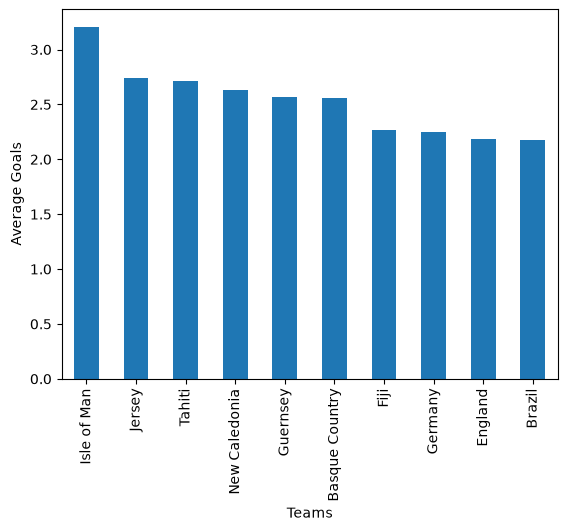

In [6]:
top_10_avg_goals=team_points.groupby("team")["goals"].mean().sort_values(ascending=False).head(10)
top_10_avg_goals.plot.bar()
plt.xlabel("Teams")
plt.ylabel("Average Goals")

<h1 style="width:100%;height:50px">Most shootouts in decades</h1>

Text(0, 0.5, 'Shootouts Played')

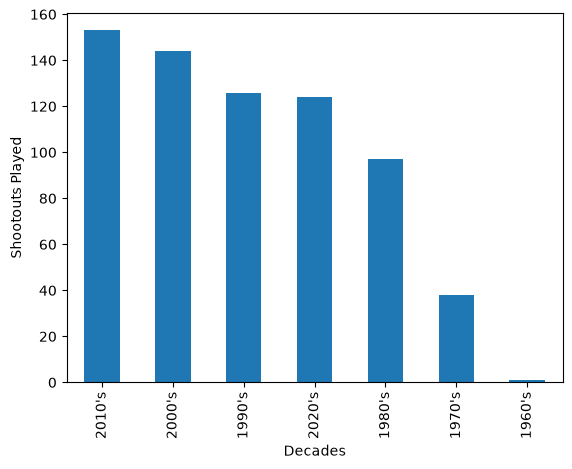

In [ ]:
shootouts=pd.read_csv("shootouts.csv")
def decade_map(date):
    year=date.split("-")[0]
    return str(year[0:3])+"0's"
shootouts["decade"]=shootouts["date"].map(decade_map)
most_decade_shootouts=shootouts["decade"].value_counts().sort_values(ascending=False).head(10)
most_decade_shootouts.plot.bar()
plt.xlabel("Decades")
plt.ylabel("Shootouts Played")

<h1 style="height:50px;">Most Shootouts by Tournaments</h1> 

Text(0, 0.5, 'Penalty Shootouts')

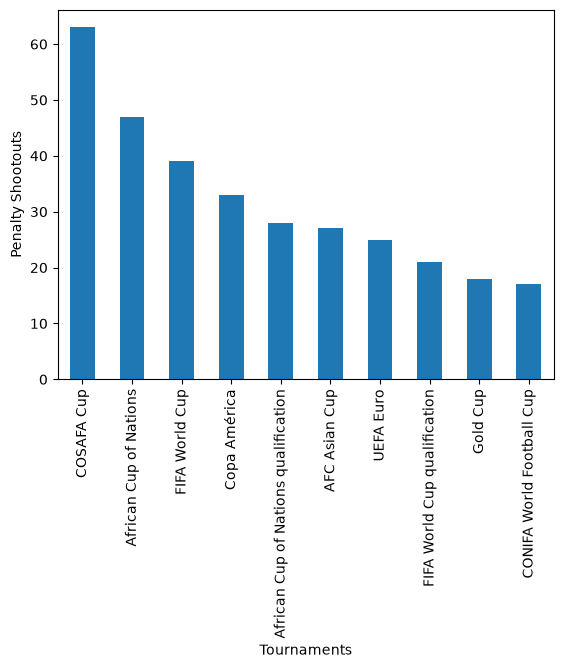

In [8]:
shootouts=pd.read_csv("shootouts.csv")
results=pd.read_csv("results.csv")
conjoined_table=results.merge(shootouts[["date","home_team","away_team"]])
def tournament_map(tournament):
    if tournament=="Friendly":
        return False
    return True
conjoined_table["is_tournament"]=conjoined_table["tournament"].map(tournament_map)
conjoined_table=conjoined_table[conjoined_table["is_tournament"]==True]
conjoined_table["tournament"].value_counts().head(10).plot.bar()
plt.xlabel("Tournaments")
plt.ylabel("Penalty Shootouts")

<h1 style="height:50px;">Teams that scored first and lost</h1>

Text(0, 0.5, 'Losses')

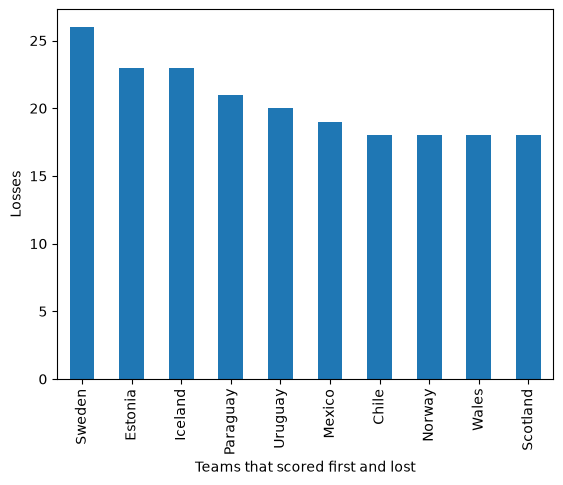

In [9]:
goalscores=pd.read_csv("goalscorers.csv")
results=pd.read_csv("results.csv")  
results=results.merge(goalscores)
results["first_score"]=~ (results.duplicated(subset=["date","home_team","away_team"]))
results=results[results["first_score"]==True]
results=results[  ((results["team"]==results["home_team"])&(results["home_score"]<results["away_score"])) | ((results["team"]==results["away_team"])&(results["away_score"]<results["home_score"]))]  
scored_yet_lost=results["team"].value_counts().head(10)
scored_yet_lost.plot.bar()
plt.xlabel("Teams that scored first and lost")
plt.ylabel("Losses")

<h1 style="height:50px;">Draw rates,Goals per match, and Winning rates changes by each decade</h1>

<Axes: xlabel='decade'>

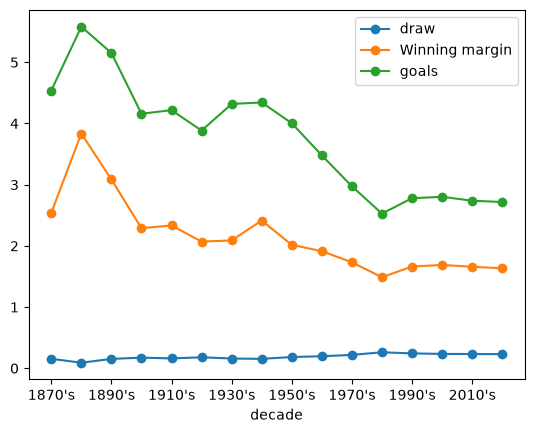

In [21]:
results=pd.read_csv("results.csv")
def decade_map(date):
    year=date.split("-")[0]
    return str(year[0:3])+"0's"
results["decade"]=results["date"].map(decade_map)
results["draw"]=results["home_score"]==results["away_score"]
results["Winning margin"]=abs(results["home_score"]-results["away_score"])
results["goals"]=results["home_score"]+results["away_score"]
results.groupby("decade")[["draw","Winning margin","goals"]].mean().plot(marker="o")


<h1 style="height:60px; color:red">Task 2.2</h1>